# Core

> A convenience PyTorch Dataset factory for the IEMOCAP emotional speech dataset.

In [ ]:
#| default_exp core

In [ ]:
#| export

import io
import json
import os
import requests
import shutil
import sqlite3
import tempfile
from pathlib import Path
from typing import Literal
from unittest.mock import patch, MagicMock

import librosa
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import soundfile as sf
import torch
import torchaudio
import torchaudio.transforms as T
from IPython.display import Audio, display
from torch.utils.data import Dataset
from tqdm.auto import tqdm

In [ ]:
#| export


class AudioChunksDataset(Dataset):

    LABELS_EMOTIONS = [
        "frustrated",
        "angry",
        "sad",
        "disgust",
        "excited",
        "fear",
        "neutral",
        "surprise",
        "happy",
    ]
    TOP_DB = 80

    def __init__(
        self,
        df_dataset_audio_chunks: pd.DataFrame,
        db_path: Path,
        sample_rate: int,
       chunk_threshold_seconds: float,
        n_fft: int,
        hop_length: int,
        win_length: int,
        n_mels: int,
        melspec_lib: Literal["torchaudio", "librosa"] = "torchaudio",
    ):
        self.df_dataset_audio_chunks = df_dataset_audio_chunks
        self.db_path = db_path
        self.sample_rate = sample_rate
        self.chunk_threshold_seconds = chunk_threshold_seconds
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.n_mels = n_mels
        self.melspec_lib = melspec_lib

        self.max_frequency = self.sample_rate / 2
        self.maxchunk_sample_frames = int(chunk_threshold_seconds * sample_rate)
        self.max_mel_timeframes = self.maxchunk_sample_frames / self.hop_length + 1

        # Torch audio transforms
        self.mel_spectrogram_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            center=True,
            pad_mode="reflect",
            power=2.0,
            norm='slaney',
            n_mels=n_mels,
            mel_scale="htk",
            f_max=self.max_frequency,
        )
        self.amp_to_db_transform = T.AmplitudeToDB(stype="power", top_db=self.TOP_DB)

        self.conn = None

    def __len__(self):
        return len(self.df_dataset_audio_chunks)

    def __getitem__(self, idx: int):
        dataset_row = self.df_dataset_audio_chunks.iloc[idx]
        source_row_index = dataset_row["source_dataset_row_index"]

        audio_array, sr = self.get_item_audio_bytes(idx)

        if self.melspec_lib == "librosa":
            # Calculate log mel spectrogram
            mel_spec = librosa.feature.melspectrogram(
                y=audio_array,
                sr=sr,
                n_fft=self.n_fft,
                hop_length=self.hop_length,
                win_length=self.win_length,
                n_mels=self.n_mels,
                fmax=self.max_frequency,
            )

            # Convert power scale → log scale (closer to human hearing)
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            features = torch.tensor(log_mel_spec, dtype=torch.float32)
        else:
            audio_tensor = torch.tensor(audio_array, dtype=torch.float32)

            # torchaudio expects (channels, time)
            audio_tensor = audio_tensor.unsqueeze(0) # mono

            mel_specs = self.mel_spectrogram_transform(audio_tensor)

            # Get the mel matrix for the only channel and
            # convert power scale → log scale (closer to human hearing)
            features = self.amp_to_db_transform(mel_specs[0])
            features = features - features.max()  # now in (-80, 0] like librosa

        labels = self._build_labels_tensor(dataset_row)

        assert features.shape[0] == self.n_mels
        assert features.shape[1] == self.max_mel_timeframes
        assert len(labels) == len(self.LABELS_EMOTIONS)

        return features, labels

    def get_item_audio_bytes(self, idx: int) -> tuple[npt.NDArray, int]:
        dataset_row = self.df_dataset_audio_chunks.iloc[idx]
        db_row = self._fetch_db_record(dataset_row["source_dataset_row_index"])

        audio_bytes = db_row["audio_bytes"]

        # Decode audio using soundfile
        audio_array, sr = sf.read(io.BytesIO(audio_bytes), dtype="float32")

        # Slice the audio
        start = int(dataset_row["start_sample_offset"])
        end = int(dataset_row["end_sample_offset"])
        sliced_audio = audio_array[start:end]

        # Padding or trimming
        if len(sliced_audio) < self.maxchunk_sample_frames:
            sliced_audio = np.pad(sliced_audio, (0, self.maxchunk_sample_frames - len(sliced_audio)))

        assert len(sliced_audio) == self.maxchunk_sample_frames

        return sliced_audio, sr

    def play_item_audio(self, idx: int):
        audio_array, sr = self.get_item_audio_bytes(idx)
        display(Audio(audio_array, rate=sr))

    def plot_melspectrogram(self, idx: int):
        dataset_row = self.df_dataset_audio_chunks.iloc[idx]
        db_row = self._fetch_db_record(dataset_row["source_dataset_row_index"])

        features, _ = self[idx]
        spec = features.numpy().astype(np.float32)

        fig, ax = plt.subplots(figsize=(10, 4))

        total_chunk_parts = dataset_row.get("total_chunk_parts")
        chunk_part_idx = dataset_row.get("chunk_part_idx")
        if total_chunk_parts > 0:
            title = f"Chunk {int(chunk_part_idx) + 1} of {int(total_chunk_parts)}"
        else:
            title = "Single-Chunk"
        title += f'  |  {db_row["major_emotion"]}'

        img = ax.imshow(spec, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(title)
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Mel bands")
        plt.colorbar(img, ax=ax, format="%+2.0f dB")

        transcription = db_row["transcription"]
        if transcription:
            plt.suptitle(f'"{transcription.strip()}"', fontsize=11)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def get_labels_emotion_name(idx: int) -> str:
        return AudioChunksDataset.LABELS_EMOTIONS[idx]

    def _get_conn(self):
        if self.conn is None:
            self.conn = sqlite3.connect(self.db_path)
            self.conn.row_factory = sqlite3.Row
        return self.conn

    def _fetch_db_record(self, source_row_index: int) -> dict:
        conn = self._get_conn()
        cursor = conn.cursor()
        cursor.execute(
            "SELECT audio_bytes, transcription, major_emotion FROM iemocap_dataset WHERE row_index = ?",
            (int(source_row_index),),
        )
        db_row = cursor.fetchone()

        if db_row is None:
            raise ValueError(f"Could not find row_index {source_row_index} in DB.")

        return db_row

    def _build_labels_tensor(self, row: pd.Series | dict) -> torch.Tensor:
        return torch.tensor(
            [row[f"reviewed_{emo}"] for emo in self.LABELS_EMOTIONS],
            dtype=torch.float32,
        )

In [ ]:
#| export

class DatasetsFactory:

    CHUNKS_MANIFEST_JSON_FILE_NAME = "dataset_audio_chunk_groups.json"
    IEMOCAP_DB_FILE_NAME = "iemocap_dataset_table.db"
    IEMOCAP_DB_VERSION_FILE_NAME = "iemocap_dataset_version.json"
    IEMOCAP_SPEAKERS_PARTITIONS = {
        "train": [
            "Ses03__F",
            "Ses03__M",
            "Ses04__F",
            "Ses04__M",
            "Ses05__F",
            "Ses05__M"
        ],
        "validation": [
            "Ses02__F",
            "Ses02__M"
        ],
        "test": [
            "Ses01__F",
            "Ses01__M"
        ],
    }

    def __init__(
        self,
        url: str,
        override_cache_dir: Path | None = None,
        refresh_chunks_manifest_json_file: bool = True,
        refresh_iemocap_db_file: bool = True,
    ):
        self.url = url.rstrip("/")
        self.cache_dir = (
            Path(override_cache_dir)
            if override_cache_dir
            else Path.home() / ".cache" / "upc-aidl-iemocap-datasets"
        )
        self.cache_dir.mkdir(parents=True, exist_ok=True)

        self.chunks_manifest_json_path = self.cache_dir / self.CHUNKS_MANIFEST_JSON_FILE_NAME
        self.db_version_json_path = self.cache_dir / self.IEMOCAP_DB_VERSION_FILE_NAME
        self.db_path = self.cache_dir / self.IEMOCAP_DB_FILE_NAME

        # Mapped CHUNKS_MANIFEST_JSON_FILE_NAME manifest *adding* local parquet file path.
        # {dataset_audio_chunk_groups.id: dataset_audio_chunk_group | _parquet_path, ...}
        self.dataset_audio_chunk_groups = {}

        # Initial download of manifest and DB
        self._sync(refresh_chunks_manifest_json_file, refresh_iemocap_db_file)

    def clear_cached_files(self):
        """Delete specific cached files: manifest, version JSON, SQLite DB, and parquet files."""
        if self.chunks_manifest_json_path.exists():
            try:
                with open(self.chunks_manifest_json_path, "r") as f:
                    manifest_data = json.load(f)
                for group in manifest_data:
                    parquet_url = group.get("last_export_filename")
                    if parquet_url:
                        parquet_filename = self._extract_dataset_audio_chunks_file_name(parquet_url)
                        parquet_path = self.cache_dir / parquet_filename
                        if parquet_path.exists():
                            parquet_path.unlink()
            except Exception as e:
                print(f"Error reading manifest during cache clearing: {e}")

        for path in [self.chunks_manifest_json_path, self.db_version_json_path, self.db_path]:
            if path.exists():
                path.unlink()

    def _should_download_db(self) -> bool:
        should_download_db = False
        remote_version_downloaded = False

        with tempfile.TemporaryDirectory() as temp_dir:
            temp_version_path = Path(temp_dir) / self.IEMOCAP_DB_VERSION_FILE_NAME
            try:
                self._download_file(
                    f"{self.url}/{self.IEMOCAP_DB_VERSION_FILE_NAME}",
                    temp_version_path,
                    "Checking DB Version"
                )
                if temp_version_path.exists():
                    remote_version_downloaded = True
            except Exception as e:
                print(f"Failed to check remote version: {e}.")

            if remote_version_downloaded:
                if not self.db_version_json_path.exists():
                    print(f"Local version file not found. Downloading version file and database...")
                    shutil.copy2(temp_version_path, self.db_version_json_path)
                    should_download_db = True
                else:
                    try:
                        with open(self.db_version_json_path, "r") as f:
                            local_data = json.load(f)
                            local_version = local_data.get("version")
                        with open(temp_version_path, "r") as f:
                            remote_data = json.load(f)
                            remote_version = remote_data.get("version")

                        if local_version != remote_version:
                            print(f"Version mismatch! Local version: {local_version}, Remote version: {remote_version}. Will download database.")
                            should_download_db = True
                            shutil.copy2(temp_version_path, self.db_version_json_path)
                        else:
                            print(f"Local version matches remote version ({local_version}). Database download skipped.")
                    except Exception as e:
                        print(f"Error comparing versions: {e}. Re-downloading database.")
                        should_download_db = True

        if not self.db_path.exists():
            should_download_db = True

        return should_download_db

    def _sync(self, refresh_chunks_manifest_json_file: bool = True, refresh_iemocap_db_file: bool = True):
        if refresh_chunks_manifest_json_file or not self.chunks_manifest_json_path.exists():
            print(f"Downloading audio chunk dataset groups manifest...")
            self._download_file(
                f"{self.url}/{self.CHUNKS_MANIFEST_JSON_FILE_NAME}", self.chunks_manifest_json_path, "Audio Chunk Dataset Groups Manifest"
            )

        if refresh_iemocap_db_file and self._should_download_db():
            print("Downloading IEMOCAP SQLite database...")
            self._download_file(
                f"{self.url}/{self.IEMOCAP_DB_FILE_NAME}", self.db_path, "IEMOCAP SQLite DB"
            )

        with open(self.chunks_manifest_json_path, "r") as f:
            json_manifest = json.load(f)
            self.mapped_manifest = {group["id"]: group for group in json_manifest}

        for group_id, group in self.mapped_manifest.items():
            parquet_url = group["last_export_filename"]
            parquet_filename = self._extract_dataset_audio_chunks_file_name(parquet_url)
            parquet_path = self.cache_dir / parquet_filename

            if not parquet_path.exists():
                print(f"Downloading {parquet_filename}...")
                self._download_file(parquet_url, parquet_path, parquet_filename)

            # Map the path the local parquet file
            self.mapped_manifest[group_id]["_parquet_path"] = parquet_path

    def _extract_dataset_audio_chunks_file_name(self, last_export_filename_url: str) -> str:
        return last_export_filename_url.split("/")[-1]

    def _refresh_json_manifest_and_dataset_audio_chunks(self):
        if self.chunks_manifest_json_path.exists():
            self.chunks_manifest_json_path.unlink()
        self._sync(refresh_chunks_manifest_json_file=True)

    def _download_file(self, url: str, filepath: Path, desc=None):
        response = requests.get(url, stream=True)
        response.raise_for_status()
        total_size = int(response.headers.get("content-length", 0))
        block_size = 1024 * 8

        with tqdm(total=total_size, unit="B", unit_scale=True, desc=desc) as pbar:
            with open(filepath, "wb") as f:
                for buffer in response.iter_content(block_size):
                    f.write(buffer)
                    pbar.update(len(buffer))

    def get_dataset_audio_chunk_groups(self, should_refresh_local_cache: bool = False) -> pd.DataFrame:
        if should_refresh_local_cache:
            self._refresh_json_manifest_and_dataset_audio_chunks()

        return pd.DataFrame(list(self.mapped_manifest.values()))

    def build_dataset(
        self,
        id: int,
        n_fft: int,
        hop_length: int,
        win_length: int,
        n_mels: int,
        partition_type: Literal["train", "validation", "test"] | None = None,
        speaker_ids_filter: list[str] | None = None,
        should_refresh_local_cache: bool = True,
    ):
        if should_refresh_local_cache:
            self._refresh_json_manifest_and_dataset_audio_chunks()

        if partition_type and speaker_ids_filter:
            raise ValueError("`speaker_ids_filter` is not valid when `partition_type` argument is provided")
        elif partition_type:
            speaker_ids_filter = self.IEMOCAP_SPEAKERS_PARTITIONS[partition_type]

        # Find the group
        group = self.mapped_manifest[id]

        parquet_url = group["last_export_filename"]
        parquet_filename = self._extract_dataset_audio_chunks_file_name(parquet_url)
        parquet_path = self.cache_dir / parquet_filename
        
        schema = pq.read_schema(parquet_path)
        field_idx = schema.names.index('should_exclude')
        should_exclude_type = schema.types[field_idx]

        # If it is not boolean (e.g. it is integer/numeric),
        # we compare against 0. Otherwise, we compare against False.
        exclude_val = False
        if not pa.types.is_boolean(should_exclude_type):
            exclude_val = 0

        filters = [
            [('should_exclude', '==', exclude_val)],  # Condition 1
        ]
        if speaker_ids_filter:
            # AND Condition 2
            filters[0].append(('speaker_id', 'in', speaker_ids_filter))

        df = pd.read_parquet(parquet_path, filters=filters)
        df = df[df["should_exclude"] == False].copy()
        df = df.reset_index(drop=True)

        return AudioChunksDataset(
            df_dataset_audio_chunks=df,
            db_path=self.db_path,
            sample_rate=group["sample_rate"],
            chunk_threshold_seconds=group["chunk_threshold_seconds"],
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
        )


## Tests

We can test the datasets factory by stubbing out the remote R2 downloads and providing a temporary SQLite database and parquet files.

In [ ]:
from unittest.mock import patch

from nbdev_upc_aidl_iemocap_datasets.test_utils import create_test_fixtures

In [ ]:
tmpdir, tests_path = create_test_fixtures()

Test the DatasetsFactory initalization

In [ ]:
# Test connection error
try:
    factory = DatasetsFactory(
        url="http://example.com",
        override_cache_dir=tests_path,
    )
    raise AssertionError("The download function should throw an error when datasets from example.com")
except requests.exceptions.RequestException:
    print("✅ The download function is not patched.")

✅ The download function is not patched.


In [ ]:
# Test cache read
temp_json_file_path = tests_path / DatasetsFactory.CHUNKS_MANIFEST_JSON_FILE_NAME
assert temp_json_file_path.exists()
factory = DatasetsFactory(
    url="http://example.com",
    override_cache_dir=tests_path,
    refresh_chunks_manifest_json_file=False,
    refresh_iemocap_db_file=False,
)
df_manifest = factory.get_dataset_audio_chunk_groups()
assert len(df_manifest) == 1
print("✅ Factory manifest listing works from test cache.")

✅ Factory manifest listing works from test cache.


In [ ]:
with patch.object(DatasetsFactory, "_download_file") as mock_download_file:
    # Initialize factory pointing to our temp cache directory
    test_url = "http://example.com/"

    factory = DatasetsFactory(
        url=test_url,
        override_cache_dir=tests_path,
    )
    # The first call should download the manifest, and the second should check the database version
    assert mock_download_file.call_count == 2
    mock_download_file.assert_any_call(
        test_url + DatasetsFactory.CHUNKS_MANIFEST_JSON_FILE_NAME,
        temp_json_file_path,
        "Audio Chunk Dataset Groups Manifest",
    )
    assert mock_download_file.call_args_list[1][0][0] == test_url + DatasetsFactory.IEMOCAP_DB_VERSION_FILE_NAME
    assert mock_download_file.call_args_list[1][0][2] == "Checking DB Version"

    df_manifest = factory.get_dataset_audio_chunk_groups()
    assert len(df_manifest) == 1
    print("✅ Factory manifest listing works!")

✅ Factory manifest listing works!


Test building a dataset from DatasetFactory

In [ ]:
ds = factory.build_dataset(
    partition_type="test",
    id=1,
    n_fft=1024,
    hop_length=200,
    win_length=400,
    n_mels=80,
    should_refresh_local_cache=False
)
assert len(ds) == 3

ds = factory.build_dataset(
    partition_type="validation",
    id=1,
    n_fft=1024,
    hop_length=200,
    win_length=400,
    n_mels=80,
    should_refresh_local_cache=False
)
assert len(ds) == 0

print("✅ Dataset building by partition works!")

✅ Dataset building by partition works!


In [ ]:
ds = factory.build_dataset(
    speaker_ids_filter=["Ses01__F"],
    id=1,
    n_fft=1024,
    hop_length=200,
    win_length=400,
    n_mels=80,
    should_refresh_local_cache=False
)
assert len(ds) == 3

ds = factory.build_dataset(
    speaker_ids_filter=["missing_speaker_id"],
    id=1,
    n_fft=1024,
    hop_length=200,
    win_length=400,
    n_mels=80,
    should_refresh_local_cache=False
)
assert len(ds) == 0

print("✅ Dataset building with speaker ids filter works!")

✅ Dataset building with speaker ids filter works!


In [ ]:
ds = factory.build_dataset(
    id=1, n_fft=1024, hop_length=200, win_length=400, n_mels=80, should_refresh_local_cache=False
)
assert len(ds) == 3
print("✅ Dataset building works!")


✅ Dataset building works!


In [ ]:
# Test retrieving the first item
features, labels = ds[0]

# n_mels = 80, so features tensor should have 80 mel frequency bins
assert features.shape[0] == 80

# total time frames = chunk_threshold_seconds / (hop_length / sample_rate)
assert features.shape[1] == 385

# Check labels
assert labels.shape[0] == len(AudioChunksDataset.LABELS_EMOTIONS)
assert torch.allclose(
    labels,
    torch.tensor(
        [0.635, 0.320, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006]
    ),
)
for i, emotion in enumerate(AudioChunksDataset.LABELS_EMOTIONS):
    assert emotion == AudioChunksDataset.get_labels_emotion_name(i)
print("✅ Feature extraction and label tensor generation works!")

✅ Feature extraction and label tensor generation works!


In [ ]:
ds.play_item_audio(0)

Test melspec transformation library

lib_name='librosa'


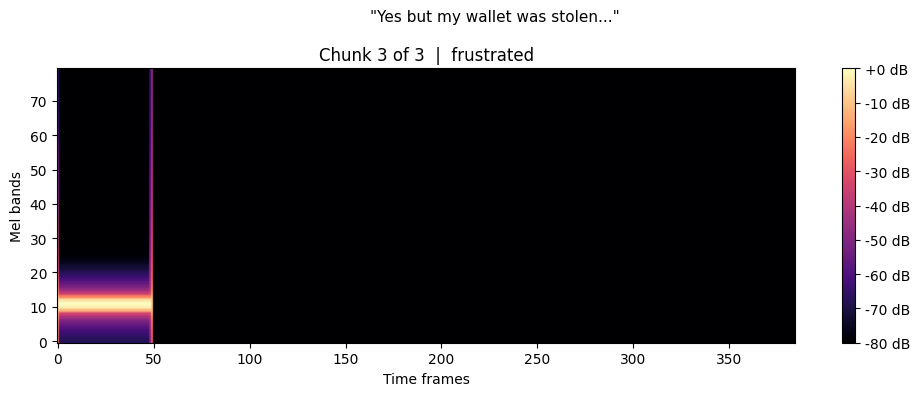

lib_name='torchaudio'


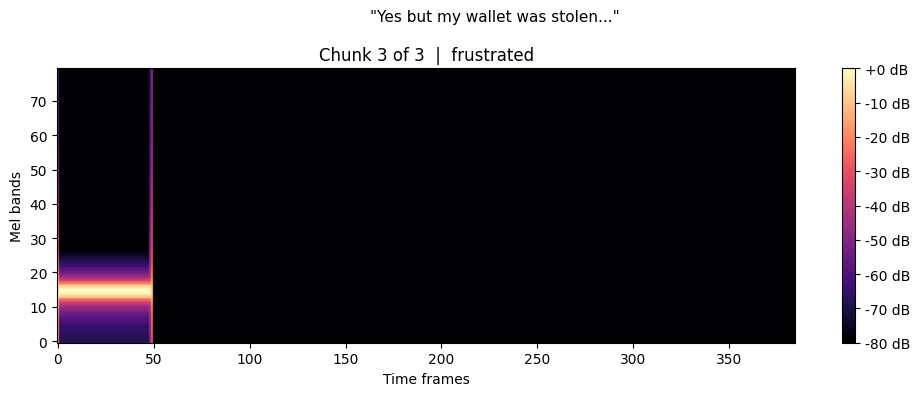

In [ ]:
test_melspec_lib_results = {
    "librosa": None,
    "torchaudio": None,
}

test_idx = 2
for lib_name, _ in test_melspec_lib_results.items():
    print(f"{lib_name=}")
    ds.melspec_lib = lib_name
    features, labels = ds[test_idx]
    test_melspec_lib_results[lib_name] = (features, labels)
    ds.plot_melspectrogram(test_idx)
    assert features.max() == 0
    assert features.min() == -80

# Check features results
assert test_melspec_lib_results["librosa"][0].shape == test_melspec_lib_results["torchaudio"][0].shape
assert test_melspec_lib_results["librosa"][1].shape == test_melspec_lib_results["torchaudio"][1].shape
assert not torch.equal(test_melspec_lib_results["librosa"][0], test_melspec_lib_results["torchaudio"][0])

# Check target results
assert torch.equal(test_melspec_lib_results["librosa"][1], test_melspec_lib_results["torchaudio"][1])

In [ ]:
# Test clear_cached_files and version checking logic

with tempfile.TemporaryDirectory() as test_cache_dir_str:
    test_cache_path = Path(test_cache_dir_str)
    
    # 1. Setup local files to mock a cached state
    local_manifest_path = test_cache_path / DatasetsFactory.CHUNKS_MANIFEST_JSON_FILE_NAME
    local_version_path = test_cache_path / DatasetsFactory.IEMOCAP_DB_VERSION_FILE_NAME
    local_db_path = test_cache_path / DatasetsFactory.IEMOCAP_DB_FILE_NAME
    local_parquet_path = test_cache_path / "group_id_1__last_export_1778968883.parquet"
    
    # Write dummy local files
    manifest_data = [{
        "id": 1,
        "chunk_threshold_seconds": 4.8,
        "previous_overlap_seconds": 0.2,
        "sample_rate": 16000,
        "last_export_filename": "http://example.com/dataset_audio_chunks/group_id_1__last_export_1778968883.parquet",
        "last_export_at": "2026-05-16 22:01:23.000000"
    }]
    with open(local_manifest_path, "w") as f:
        json.dump(manifest_data, f)
    with open(local_version_path, "w") as f:
        json.dump({"version": 1}, f)
    local_db_path.touch()
    local_parquet_path.touch()
    
    # Initialize factory with refresh flags set to False to load from cache
    factory = DatasetsFactory(
        url="http://example.com",
        override_cache_dir=test_cache_path,
        refresh_chunks_manifest_json_file=False,
        refresh_iemocap_db_file=False
    )
    
    # Verify that files exist initially
    assert local_manifest_path.exists()
    assert local_version_path.exists()
    assert local_db_path.exists()
    assert local_parquet_path.exists()
    
    # Clear cache
    factory.clear_cached_files()
    
    # Verify files are deleted
    assert not local_manifest_path.exists()
    assert not local_version_path.exists()
    assert not local_db_path.exists()
    assert not local_parquet_path.exists()
    print("✅ clear_cached_files deletes all expected files successfully!")

# 2. Test version check logic (mismatch vs match)
with tempfile.TemporaryDirectory() as test_cache_dir_str:
    test_cache_path = Path(test_cache_dir_str)
    
    local_manifest_path = test_cache_path / DatasetsFactory.CHUNKS_MANIFEST_JSON_FILE_NAME
    local_version_path = test_cache_path / DatasetsFactory.IEMOCAP_DB_VERSION_FILE_NAME
    local_db_path = test_cache_path / DatasetsFactory.IEMOCAP_DB_FILE_NAME
    
    # Write dummy local version 1 and db
    manifest_data = [{
        "id": 1,
        "chunk_threshold_seconds": 4.8,
        "previous_overlap_seconds": 0.2,
        "sample_rate": 16000,
        "last_export_filename": "http://example.com/dataset_audio_chunks/group_id_1__last_export_1778968883.parquet",
        "last_export_at": "2026-05-16 22:01:23.000000"
    }]
    with open(local_manifest_path, "w") as f:
        json.dump(manifest_data, f)
    with open(local_version_path, "w") as f:
        json.dump({"version": 1}, f)
    local_db_path.touch()
    
    # Case A: Remote version matches local version (version 1)
    def mock_download(url, filepath, desc=None):
        if DatasetsFactory.IEMOCAP_DB_VERSION_FILE_NAME in str(url):
            with open(filepath, "w") as f:
                json.dump({"version": 1}, f)
        elif "group_id_1" in str(url):
            Path(filepath).touch()
            
    with patch.object(DatasetsFactory, "_download_file", side_effect=mock_download) as mock_dl:
        factory = DatasetsFactory(
            url="http://example.com",
            override_cache_dir=test_cache_path,
            refresh_chunks_manifest_json_file=False,
            refresh_iemocap_db_file=True
        )
        # Should not call download for DB file
        db_download_calls = [c for c in mock_dl.call_args_list if DatasetsFactory.IEMOCAP_DB_FILE_NAME in str(c[0][0])]
        assert len(db_download_calls) == 0
        print("✅ Matching version skips database download!")

    # Case B: Remote version mismatches local version (version 2)
    # Reset local version
    with open(local_version_path, "w") as f:
        json.dump({"version": 1}, f)
    local_db_path.touch()
    
    def mock_download_mismatch(url, filepath, desc=None):
        if DatasetsFactory.IEMOCAP_DB_VERSION_FILE_NAME in str(url):
            with open(filepath, "w") as f:
                json.dump({"version": 2}, f)
        elif DatasetsFactory.IEMOCAP_DB_FILE_NAME in str(url):
            Path(filepath).touch()
        elif "group_id_1" in str(url):
            Path(filepath).touch()

    with patch.object(DatasetsFactory, "_download_file", side_effect=mock_download_mismatch) as mock_dl:
        factory = DatasetsFactory(
            url="http://example.com",
            override_cache_dir=test_cache_path,
            refresh_chunks_manifest_json_file=False,
            refresh_iemocap_db_file=True
        )
        # Should call download for DB file
        db_download_calls = [c for c in mock_dl.call_args_list if DatasetsFactory.IEMOCAP_DB_FILE_NAME in str(c[0][0])]
        assert len(db_download_calls) == 1
        # Local version should be updated to 2
        with open(local_version_path, "r") as f:
            assert json.load(f)["version"] == 2
        print("✅ Mismatched version triggers database download and updates local version file!")

✅ clear_cached_files deletes all expected files successfully!
Local version matches remote version (1). Database download skipped.
✅ Matching version skips database download!
Version mismatch! Local version: 1, Remote version: 2. Will download database.
✅ Mismatched version triggers database download and updates local version file!


In [ ]:
# Tests temporary directory clean-up
tmpdir.cleanup()